In [241]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from pycaret.classification import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,roc_curve,auc,classification_report
import pickle

In [142]:
df = pd.read_csv('transaction_dataset.csv',index_col=0)

In [143]:
pd.set_option('display.max_rows',None)

In [144]:
df.head()

,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [145]:
df.shape

(9841, 50)

In [146]:
setup(df,target="FLAG",session_id = 85)

,Description,Value
0,Session id,85
1,Target,FLAG
2,Target type,Binary
3,Original data shape,"(9841, 50)"
4,Transformed data shape,"(9841, 50)"
5,Transformed train set shape,"(6888, 50)"
6,Transformed test set shape,"(2953, 50)"
7,Numeric features,46
8,Categorical features,3
9,Rows with missing values,27.6%


In [147]:
# compare_models()

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9841 entries, 0 to 9840
Data columns (total 50 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Index                                                 9841 non-null   int64  
 1   Address                                               9841 non-null   object 
 2   FLAG                                                  9841 non-null   int64  
 3   Avg min between sent tnx                              9841 non-null   float64
 4   Avg min between received tnx                          9841 non-null   float64
 5   Time Diff between first and last (Mins)               9841 non-null   float64
 6   Sent tnx                                              9841 non-null   int64  
 7   Received Tnx                                          9841 non-null   int64  
 8   Number of Created Contracts                           9841 non-

In [149]:
for col in df :
    print(f'{col}',len(df[col].unique()))

Index 4729
Address 9816
FLAG 2
Avg min between sent tnx 5013
Avg min between received tnx 6223
Time Diff between first and last (Mins) 7810
Sent tnx 641
Received Tnx 727
Number of Created Contracts 20
Unique Received From Addresses 256
Unique Sent To Addresses 258
min value received 4589
max value received  6302
avg val received 6767
min val sent 4719
max val sent 6647
avg val sent 5854
min value sent to contract 3
max val sent to contract 4
avg value sent to contract 4
total transactions (including tnx to create contract 897
total Ether sent 5868
total ether received 6728
total ether sent contracts 4
total ether balance 5717
 Total ERC20 tnxs 301
 ERC20 total Ether received 3461
 ERC20 total ether sent 1416
 ERC20 total Ether sent contract 30
 ERC20 uniq sent addr 108
 ERC20 uniq rec addr 148
 ERC20 uniq sent addr.1 5
 ERC20 uniq rec contract addr 124
 ERC20 avg time between sent tnx 2
 ERC20 avg time between rec tnx 2
 ERC20 avg time between rec 2 tnx 2
 ERC20 avg time between contra

In [150]:
df.select_dtypes(include=['float','int']).describe()

,Index,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,...,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
count,9841.000000,9841.000000,9841.000000,9841.000000,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,...,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9012.0,9012.0,9012.0,9012.000000,9012.000000
mean,1815.049893,0.221421,5086.878721,8004.851184,2.183333e+05,115.931714,163.700945,3.729702,30.360939,25.840159,...,1.252524e+08,4.346203e+06,1.174126e+04,1.303594e+07,6.318389e+06,0.0,0.0,0.0,1.384931,4.826676
std,1222.621830,0.415224,21486.549974,23081.714801,3.229379e+05,757.226361,940.836550,141.445583,298.621112,263.820410,...,1.053741e+10,2.141192e+08,1.053567e+06,1.179905e+09,5.914764e+08,0.0,0.0,0.0,6.735121,16.678607
min,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
25%,821.000000,0.000000,0.000000,0.000000,3.169300e+02,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
50%,1641.000000,0.000000,17.340000,509.770000,4.663703e+04,3.000000,4.000000,0.000000,2.000000,2.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,1.000000
75%,2601.000000,0.000000,565.470000,5480.390000,3.040710e+05,11.000000,27.000000,0.000000,5.000000,3.000000,...,9.900000e+01,2.946467e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,2.000000
max,4729.000000,1.000000,430287.670000,482175.490000,1.954861e+06,10000.000000,10000.000000,9995.000000,9999.000000,9287.000000,...,1.000000e+12,1.724181e+10,1.000000e+08,1.120000e+11,5.614756e+10,0.0,0.0,0.0,213.000000,737.000000


In [151]:
df = df.drop(columns=['Index','Address'])

In [152]:
df.select_dtypes(include=['float','int']).describe()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
count,9841.000000,9841.000000,9841.000000,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,...,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9012.0,9012.0,9012.0,9012.000000,9012.000000
mean,0.221421,5086.878721,8004.851184,2.183333e+05,115.931714,163.700945,3.729702,30.360939,25.840159,43.845153,...,1.252524e+08,4.346203e+06,1.174126e+04,1.303594e+07,6.318389e+06,0.0,0.0,0.0,1.384931,4.826676
std,0.415224,21486.549974,23081.714801,3.229379e+05,757.226361,940.836550,141.445583,298.621112,263.820410,325.929139,...,1.053741e+10,2.141192e+08,1.053567e+06,1.179905e+09,5.914764e+08,0.0,0.0,0.0,6.735121,16.678607
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,3.169300e+02,1.000000,1.000000,0.000000,1.000000,1.000000,0.001000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
50%,0.000000,17.340000,509.770000,4.663703e+04,3.000000,4.000000,0.000000,2.000000,2.000000,0.095856,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,1.000000
75%,0.000000,565.470000,5480.390000,3.040710e+05,11.000000,27.000000,0.000000,5.000000,3.000000,2.000000,...,9.900000e+01,2.946467e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,2.000000
max,1.000000,430287.670000,482175.490000,1.954861e+06,10000.000000,10000.000000,9995.000000,9999.000000,9287.000000,10000.000000,...,1.000000e+12,1.724181e+10,1.000000e+08,1.120000e+11,5.614756e+10,0.0,0.0,0.0,213.000000,737.000000


### As we can see it is a highly imbalanced dataset.

In [153]:
df['FLAG'].value_counts()

FLAG
0    7662
1    2179
Name: count, dtype: int64

In [154]:
fig = px.pie(df,values=df['FLAG'].value_counts().values,names=df['FLAG'].value_counts())
fig.show()

In [155]:
df.isnull().sum()

FLAG                                                       0
Avg min between sent tnx                                   0
Avg min between received tnx                               0
Time Diff between first and last (Mins)                    0
Sent tnx                                                   0
Received Tnx                                               0
Number of Created Contracts                                0
Unique Received From Addresses                             0
Unique Sent To Addresses                                   0
min value received                                         0
max value received                                         0
avg val received                                           0
min val sent                                               0
max val sent                                               0
avg val sent                                               0
min value sent to contract                                 0
max val sent to contract

In [156]:
df.columns

Index(['FLAG', 'Avg min between sent tnx', 'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx',
       ' ERC20

In [157]:
df = df.drop(columns=[' ERC20 most sent token type',' ERC20_most_rec_token_type'])

In [158]:
df.fillna(df.median(),inplace=True)

In [159]:
df.isnull().sum()

FLAG                                                    0
Avg min between sent tnx                                0
Avg min between received tnx                            0
Time Diff between first and last (Mins)                 0
Sent tnx                                                0
Received Tnx                                            0
Number of Created Contracts                             0
Unique Received From Addresses                          0
Unique Sent To Addresses                                0
min value received                                      0
max value received                                      0
avg val received                                        0
min val sent                                            0
max val sent                                            0
avg val sent                                            0
min value sent to contract                              0
max val sent to contract                                0
avg value sent

In [160]:
no_var = df.var(numeric_only=True) == 0
no_var

FLAG                                                    False
Avg min between sent tnx                                False
Avg min between received tnx                            False
Time Diff between first and last (Mins)                 False
Sent tnx                                                False
Received Tnx                                            False
Number of Created Contracts                             False
Unique Received From Addresses                          False
Unique Sent To Addresses                                False
min value received                                      False
max value received                                      False
avg val received                                        False
min val sent                                            False
max val sent                                            False
avg val sent                                            False
min value sent to contract                              False
max val 

### Some columns are missing ?
like below

In [161]:
df[' Total ERC20 tnxs'].apply(type).value_counts
# the problem was using df.median without paranteses that filled our cells with the python method 

<bound method IndexOpsMixin.value_counts of 0       <class 'float'>
1       <class 'float'>
2       <class 'float'>
3       <class 'float'>
4       <class 'float'>
             ...       
9836    <class 'float'>
9837    <class 'float'>
9838    <class 'float'>
9839    <class 'float'>
9840    <class 'float'>
Name:  Total ERC20 tnxs, Length: 9841, dtype: object>

### Deleting datas that has no effect with variance 0 

In [162]:
no_var = df.var(numeric_only=True) == 0
df.var()[no_var]

 ERC20 avg time between sent tnx        0.0
 ERC20 avg time between rec tnx         0.0
 ERC20 avg time between rec 2 tnx       0.0
 ERC20 avg time between contract tnx    0.0
 ERC20 min val sent contract            0.0
 ERC20 max val sent contract            0.0
 ERC20 avg val sent contract            0.0
dtype: float64

In [163]:
df.drop(df.var()[no_var].index,axis=1,inplace = True)

In [164]:
df.shape

(9841, 39)

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9841 entries, 0 to 9840
Data columns (total 39 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg min between sent tnx                              9841 non-null   float64
 2   Avg min between received tnx                          9841 non-null   float64
 3   Time Diff between first and last (Mins)               9841 non-null   float64
 4   Sent tnx                                              9841 non-null   int64  
 5   Received Tnx                                          9841 non-null   int64  
 6   Number of Created Contracts                           9841 non-null   int64  
 7   Unique Received From Addresses                        9841 non-null   int64  
 8   Unique Sent To Addresses                              9841 non-

### Deleting features with high correlations with each other

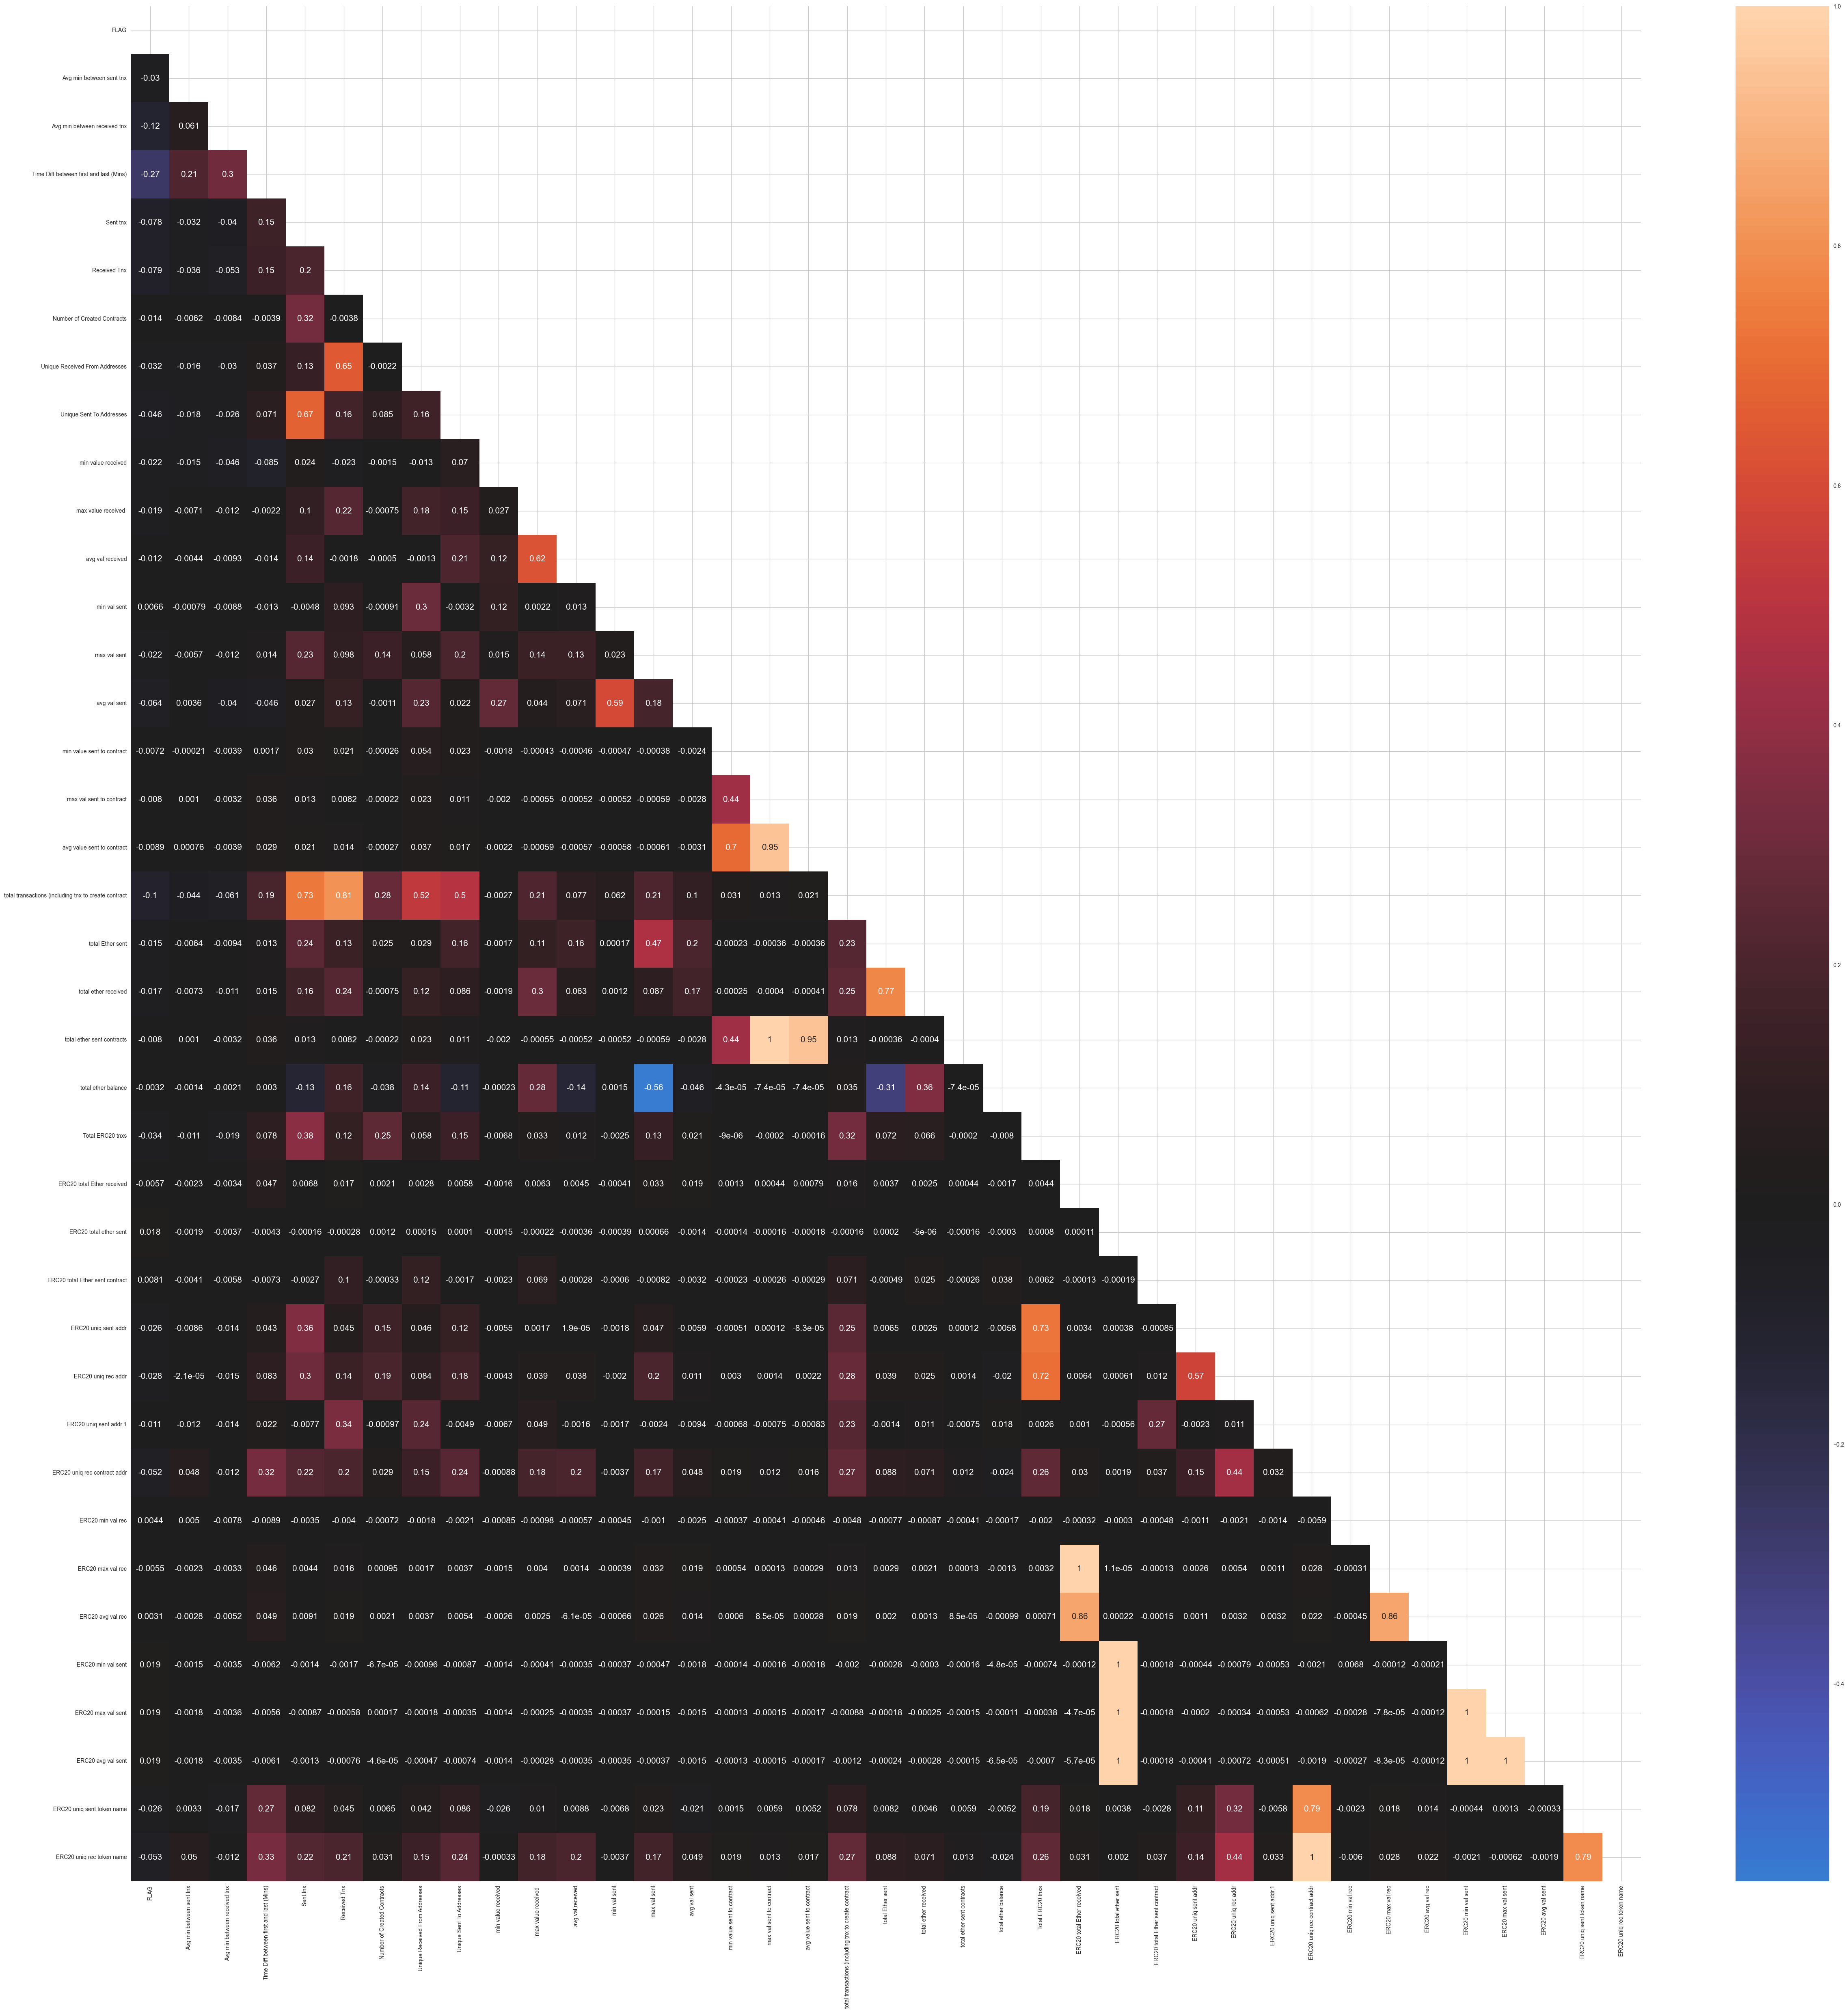

In [166]:
corr = df.corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
plt.figure(figsize=(60,60))
sns.heatmap(corr,
            annot=True,
            mask = mask,
            annot_kws={'size':15},
            center=0)
plt.show()

In [167]:
corr.sort_values(by=['FLAG'],key=abs)

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 uniq sent token name,ERC20 uniq rec token name
ERC20 avg val rec,0.003132,-0.002829,-0.005241,0.049160,0.009104,0.019382,0.002096,0.003741,0.005412,-0.002610,...,0.003207,0.021501,-0.000455,0.859766,1.000000,-0.000205,-0.000117,-0.000123,0.013764,0.022273
total ether balance,-0.003229,-0.001425,-0.002149,0.002955,-0.127211,0.158146,-0.037902,0.144949,-0.113428,-0.000233,...,0.018368,-0.023787,-0.000170,-0.001251,-0.000991,-0.000048,-0.000112,-0.000065,-0.005164,-0.023809
ERC20 min val rec,0.004434,0.004998,-0.007794,-0.008921,-0.003480,-0.004043,-0.000724,-0.001784,-0.002093,-0.000847,...,-0.001367,-0.005930,1.000000,-0.000311,-0.000455,0.006815,-0.000280,-0.000265,-0.002288,-0.006013
ERC20 max val rec,-0.005510,-0.002260,-0.003326,0.046278,0.004445,0.015522,0.000946,0.001691,0.003696,-0.001528,...,0.001051,0.027598,-0.000311,1.000000,0.859766,-0.000121,-0.000078,-0.000083,0.017746,0.028497
ERC20 total Ether received,-0.005711,-0.002339,-0.003430,0.046570,0.006840,0.016648,0.002099,0.002832,0.005809,-0.001580,...,0.001031,0.030039,-0.000322,0.999967,0.859823,-0.000125,-0.000047,-0.000057,0.018349,0.030934
min val sent,0.006626,-0.000789,-0.008761,-0.013107,-0.004846,0.093448,-0.000913,0.296240,-0.003166,0.117682,...,-0.001735,-0.003749,-0.000446,-0.000393,-0.000663,-0.000369,-0.000366,-0.000353,-0.006785,-0.003728
min value sent to contract,-0.007213,-0.000210,-0.003916,0.001734,0.029529,0.020645,-0.000261,0.053946,0.023183,-0.001820,...,-0.000678,0.018886,-0.000372,0.000541,0.000598,-0.000144,-0.000134,-0.000134,0.001533,0.019304
max val sent to contract,-0.007988,0.001044,-0.003230,0.036162,0.013263,0.008243,-0.000225,0.023258,0.010926,-0.002015,...,-0.000750,0.012325,-0.000412,0.000133,0.000085,-0.000160,-0.000155,-0.000151,0.005911,0.012685
total ether sent contracts,-0.007988,0.001044,-0.003230,0.036162,0.013263,0.008243,-0.000225,0.023258,0.010926,-0.002015,...,-0.000750,0.012325,-0.000412,0.000133,0.000085,-0.000160,-0.000155,-0.000151,0.005911,0.012685
ERC20 total Ether sent contract,0.008127,-0.004101,-0.005813,-0.007337,-0.002652,0.104939,-0.000334,0.116755,-0.001697,-0.002331,...,0.274658,0.037021,-0.000477,-0.000125,-0.000154,-0.000184,-0.000183,-0.000177,-0.002817,0.036892


### Finding the Items that has the highest correlation with each other 

In [228]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).unstack()

# 3. Filter for pairs > 0.8 and sort
pairs[pairs > 0.80].sort_values(ascending=False)

 ERC20 avg val sent   ERC20 max val sent        0.999952
                      ERC20 min val sent        0.999785
 ERC20 max val sent   ERC20 min val sent        0.999729
                      ERC20 total ether sent    0.999649
 ERC20 avg val sent   ERC20 total ether sent    0.999566
 ERC20 min val sent   ERC20 total ether sent    0.999311
dtype: float64

In [229]:
drop = [
    ' ERC20 avg val rec',
    'total ether balance',
    ' ERC20 min val rec',
    ' ERC20 max val rec',
    ' ERC20 total Ether received',
    'min val sent',
    'min value sent to contract',
    'max val sent to contract',
    'total ether sent contracts',
    ' ERC20 total Ether sent contract',
    'avg value sent to contract',
    ' ERC20 uniq rec contract addr',
    'total transactions (including tnx to create contract'
]

df.drop(drop,axis=1,inplace=True)

KeyError: "[' ERC20 avg val rec', 'total ether balance', ' ERC20 min val rec', ' ERC20 max val rec', ' ERC20 total Ether received', 'min val sent', 'min value sent to contract', 'max val sent to contract', 'total ether sent contracts', ' ERC20 total Ether sent contract', 'avg value sent to contract', ' ERC20 uniq rec contract addr', 'total transactions (including tnx to create contract'] not found in axis"

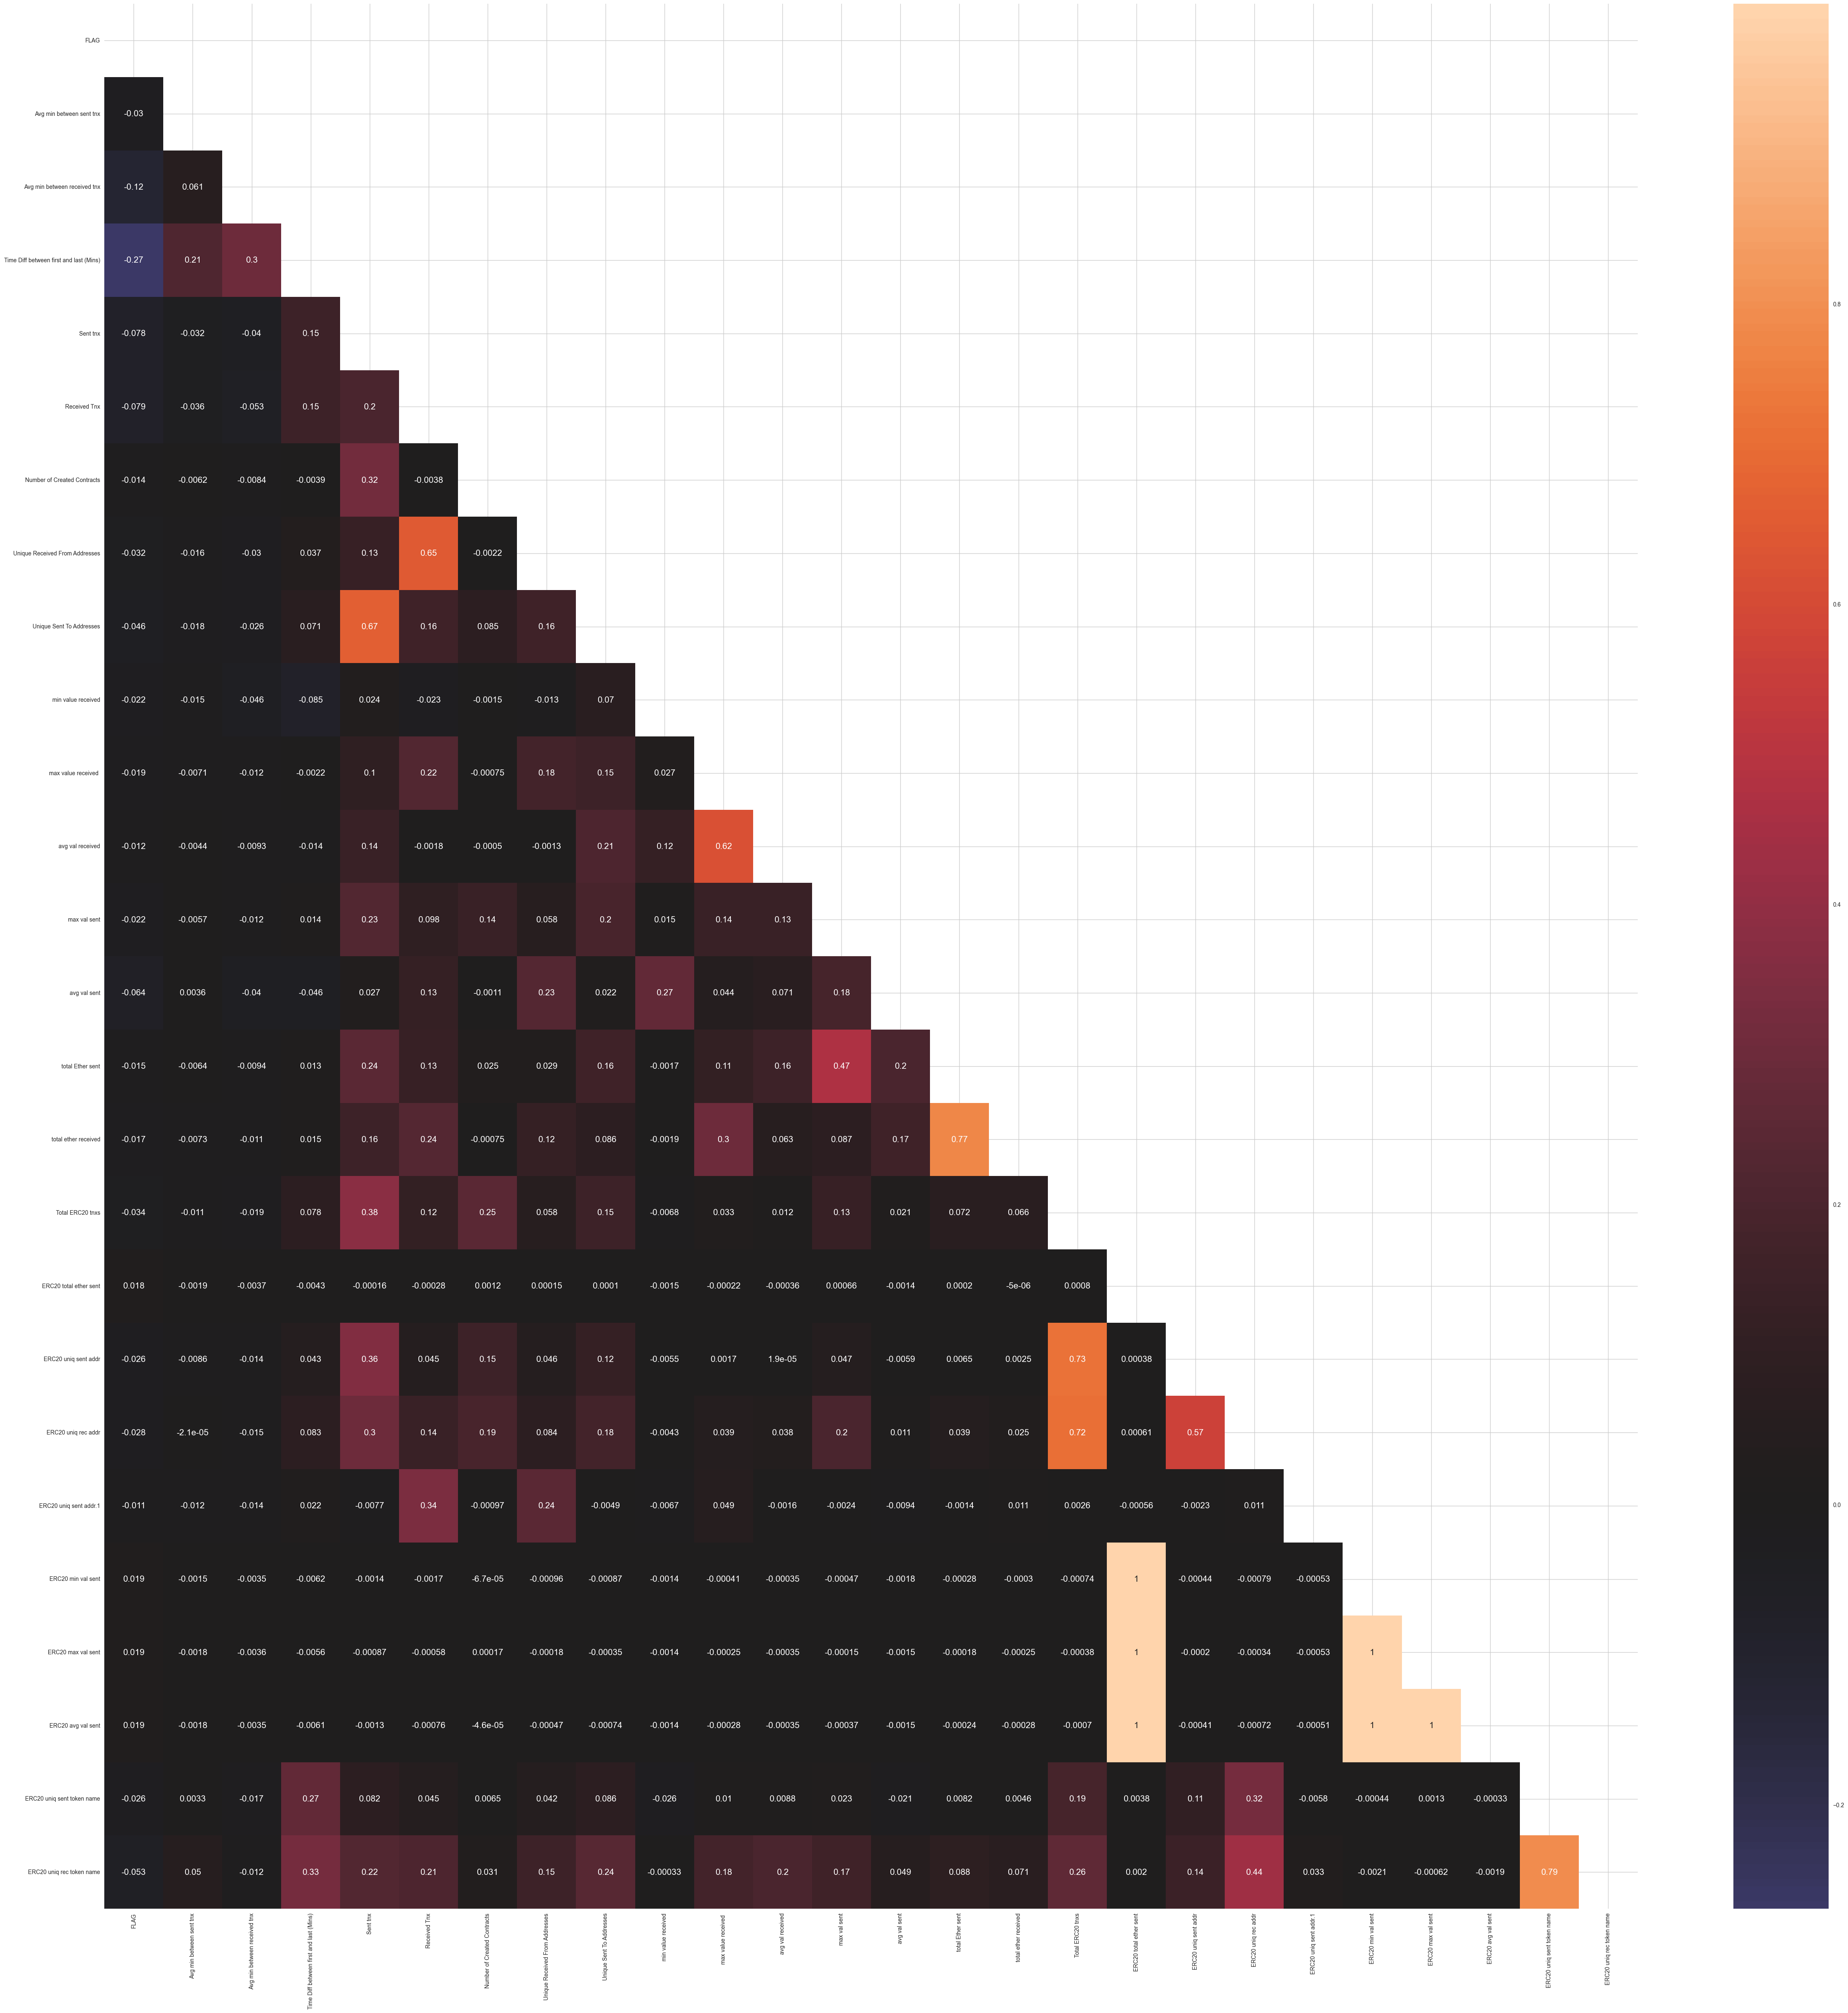

In [ ]:
corr = df.corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
plt.figure(figsize=(60,60))
sns.heatmap(corr,
            annot=True,
            mask = mask,
            annot_kws={'size':15},
            center=0)
plt.show()

Drop Features that are mostly 0s

In [ ]:
for i in df.columns[1:] :
    if len(df[i].value_counts()) < 10:
        print(f'the column {i} has the following count:\n {df[i].value_counts()}')
        print('=======================================================')

the column  ERC20 uniq sent addr.1 has the following count:
  ERC20 uniq sent addr.1
0.0    9813
1.0      26
3.0       1
2.0       1
Name: count, dtype: int64


In [ ]:
df.drop(' ERC20 uniq sent addr.1',axis=1,inplace=True)

In [ ]:
df.shape

(9841, 25)

In [ ]:
df.dtypes

FLAG                                         int64
Avg min between sent tnx                   float64
Avg min between received tnx               float64
Time Diff between first and last (Mins)    float64
Sent tnx                                     int64
Received Tnx                                 int64
Number of Created Contracts                  int64
Unique Received From Addresses               int64
Unique Sent To Addresses                     int64
min value received                         float64
max value received                         float64
avg val received                           float64
max val sent                               float64
avg val sent                               float64
total Ether sent                           float64
total ether received                       float64
 Total ERC20 tnxs                          float64
 ERC20 total ether sent                    float64
 ERC20 uniq sent addr                      float64
 ERC20 uniq rec addr           

In [ ]:
y = df.iloc[:,0]
x = df.iloc[:,1:]
print(x.shape,y.shape)

(9841, 24) (9841,)


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=123)

In [ ]:
sc = StandardScaler()
sc_train = sc.fit_transform(x_train)

In [ ]:
sc_df = pd.DataFrame(sc_train,columns=x_train.columns)
sc_df

,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,...,total ether received,Total ERC20 tnxs,ERC20 total ether sent,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 uniq sent token name,ERC20 uniq rec token name
0,-0.038167,0.310581,2.851119,0.001530,-0.133464,-0.025638,-0.066047,0.052558,-0.133168,-0.031784,...,-0.031246,0.257603,-0.011875,0.125987,0.198661,-0.011896,-0.011674,-0.011400,2.708340,1.868394
1,-0.238842,-0.339707,-0.675810,-0.153323,-0.176780,-0.025638,-0.106769,-0.098127,-0.133260,-0.043658,...,-0.033428,-0.075357,-0.012140,-0.058886,-0.075182,-0.011896,-0.011726,-0.011409,-0.197341,-0.217464
2,-0.238088,-0.322958,1.063494,1.620329,1.238207,-0.025638,-0.096588,-0.094539,-0.133226,-0.041094,...,-0.032487,-0.077685,-0.012140,-0.058886,-0.087088,-0.011896,-0.011726,-0.011409,-0.197341,-0.278813
3,-0.238842,0.503169,-0.553119,-0.153323,-0.174717,-0.018987,-0.099982,-0.098127,-0.133260,-0.043563,...,-0.033426,-0.077685,-0.012140,-0.058886,-0.087088,-0.011896,-0.011726,-0.011409,-0.197341,-0.278813
4,-0.231326,-0.339693,-0.674831,-0.150720,-0.174717,-0.025638,-0.099982,-0.090952,0.008139,-0.038450,...,-0.033180,-0.077685,-0.012140,-0.058886,-0.087088,-0.011896,-0.011726,-0.011409,-0.197341,-0.278813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7867,-0.238842,-0.320304,-0.672906,-0.152022,-0.174717,-0.025638,-0.099982,-0.094539,-0.129891,-0.043444,...,-0.033420,-0.075357,-0.012140,-0.058886,-0.075182,-0.011896,-0.011726,-0.011409,-0.197341,-0.217464
7868,-0.160852,-0.250448,0.336370,-0.140310,-0.024143,-0.025638,0.358138,-0.083776,-0.133257,-0.042296,...,-0.032907,-0.066043,-0.012140,-0.058886,-0.039464,-0.011896,-0.011726,-0.011409,-0.197341,0.027931
7869,-0.238842,-0.339707,-0.675610,-0.152022,-0.175749,-0.025638,-0.103375,-0.094539,-0.132724,-0.043642,...,-0.033428,-0.077685,-0.012140,-0.058886,-0.087088,-0.011896,-0.011726,-0.011409,-0.197341,-0.278813
7870,0.116065,0.012046,-0.061022,-0.140310,-0.161310,-0.025638,-0.062654,-0.062250,-0.133239,0.158200,...,-0.027996,-0.068372,-0.012140,-0.058886,-0.039464,-0.011896,-0.011726,-0.011409,-0.197341,-0.033418


Dealing with imbalanced dataset with SMOTE 

In [ ]:
df['FLAG'].value_counts(normalize=True) * 100

FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64

In [ ]:
oversample = SMOTE()
print(f'shape of the training data before SMOTE:{sc_train.shape,y_train.shape}')

shape of the training data before SMOTE:((7872, 24), (7872,))


In [ ]:
x_train_resample,y_train_resample = oversample.fit_resample(sc_train,y_train)
print(f'shape of the training after SMOTE:{x_train_resample.shape,y_train_resample.shape}')

shape of the training after SMOTE:((12230, 24), (12230,))


In [ ]:
# Target distribution before SMOTE 
non_fraud = 0
fraud =0 
for i in y_train:
    if i == 0:
        non_fraud+=1
    else:
        fraud+=1
print(f'before over sample non fraud:{non_fraud} fraud:{fraud}')
# Target distribution after SMOTE
non_fraud_sm = 0
fraud_sm = 0
for i in y_train_resample:
    if i == 0:
        non_fraud_sm += 1
    else:
        fraud_sm += 1
print(f'after over sample non fraud:{non_fraud_sm} fraud:{fraud_sm}')

    

before over sample non fraud:6115 fraud:1757
after over sample non fraud:6115 fraud:6115


Training On Different Models(XgBoost,RandomForest)

In [ ]:
LR = LogisticRegression()
LR.fit(x_train_resample,y_train_resample)
# Transforming test features like training step
sc_test = sc.transform(x_test)

preds = LR.predict(sc_test)

print(classification_report(y_test,preds))
print(confusion_matrix(y_test,preds))

              precision    recall  f1-score   support

           0       0.94      0.54      0.69      1547
           1       0.34      0.87      0.49       422

    accuracy                           0.61      1969
   macro avg       0.64      0.71      0.59      1969
weighted avg       0.81      0.61      0.65      1969

[[839 708]
 [ 55 367]]


In [ ]:
RF = RandomForestClassifier(random_state = 123)
RF.fit(x_train_resample,y_train_resample)
preds_RF = RF.predict(sc_test)
print(classification_report(y_test,preds_RF))
print(confusion_matrix(y_test,preds_RF))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1547
           1       0.94      0.97      0.96       422

    accuracy                           0.98      1969
   macro avg       0.97      0.98      0.97      1969
weighted avg       0.98      0.98      0.98      1969

[[1523   24]
 [  13  409]]


In [ ]:
xgb_c = xgb.XGBClassifier(random_state = 42)
xgb_c.fit(x_train_resample,y_train_resample)
preds_xgb = xgb_c.predict(sc_test)
print(classification_report(y_test,preds_xgb))
print(confusion_matrix(y_test,preds_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1547
           1       0.95      0.98      0.96       422

    accuracy                           0.98      1969
   macro avg       0.97      0.98      0.98      1969
weighted avg       0.98      0.98      0.98      1969

[[1526   21]
 [  10  412]]


Hyperparameters tuning for XGB Classifier

In [ ]:
params_grid = {
    'learning_rate': [0.01, 0.05, 0.1], 
    'n_estimators': [100, 300, 500],    
    'subsample': [0.7, 0.9, 1.0],       
    'max_depth': [3, 4, 5],             
    'colsample_bytree': [0.5, 0.7, 1.0] 
}

grid = GridSearchCV(estimator=xgb_c,param_grid=params_grid,scoring='recall',cv=10,verbose=0)
grid.fit(x_train_resample,y_train_resample)

print(f'Best params found for xgboost are :{grid.best_params_}')
print(f'Best recall obtained by the best parms :{grid.best_score_}')

Best params found for xgboost are :{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 1.0}
Best recall obtained by the best parms :0.9905092369735673


In [234]:
pred_best_xgb = grid.best_estimator_.predict(sc_test)
print(classification_report(y_test,pred_best_xgb))
print(confusion_matrix(y_test,pred_best_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1547
           1       0.96      0.98      0.97       422

    accuracy                           0.99      1969
   macro avg       0.98      0.98      0.98      1969
weighted avg       0.99      0.99      0.99      1969

[[1528   19]
 [   9  413]]
